In [1]:
import pickle as pickle

import matplotlib.pyplot as plt

from prince_cr import config, core, cross_sections, photonfields
from prince_cr.solvers import UHECRPropagationSolverBDF

CUPY not found for GPU support. Degrading to MKL.
MKL runtime not found. Degrading to scipy.


In [2]:
config.debug_level = 2
config.max_mass = 1

In [3]:
pf = photonfields.CombinedPhotonField([photonfields.CMBPhotonSpectrum, photonfields.CIBGilmore2D])

cs = cross_sections.CompositeCrossSection(
    [
        (0.0, cross_sections.TabulatedCrossSection, ("PSB",)),
        (0.14, cross_sections.SophiaSuperposition, ()),
    ]
)

CompositeCrossSection::_join_models(): Attempt to join 2 models.
TabulatedCrossSection::_load(): Load tabulated cross sections
TabulatedCrossSection::_load(): Egrid loading finished
TabulatedCrossSection::_load(): Data file loading finished
TabulatedCrossSection::set_range(): Range set to 3.16e-04 - 1.00e+00
TabulatedCrossSection::_load(): Finished initialization
TabulatedCrossSection::_reduce_channels(): Integrating out species with lifetime smaller than inf
SophiaSuperposition::_load(): Load tabulated cross sections
SophiaSuperposition::_load(): Loading SOPHIA cross sections from file.
SophiaSuperposition::_load(): Egrid loading finished
SophiaSuperposition::_load(): Data file loading finished
SophiaSuperposition::set_range(): Range set to 1.58e-01 - 1.00e+08
TabulatedCrossSection::_reduce_channels(): Cache used for decays, CacheInfo(hits=0, misses=0, maxsize=512, currsize=0)
TabulatedCrossSection::set_range(): Range set to 3.16e-04 - 1.26e-01
SophiaSuperposition::_load(): Load tabul

In [4]:
pr = core.PriNCeRun(max_mass=1, photon_field=pf, cross_sections=cs)

PriNCeRun::__init__(): initialising Energy grid
ContinuousPairProductionLossRate::__init__(): using 400 steps in xi
ContinuousPairProductionLossRate::__init__(): using 400 steps in xi
PhotoNuclearInteractionRate::_estimate_batch_matrix(): Batch matrix dimensions are 38818x72
CompositeCrossSection::resp(): First Call, creating instance of ResponseFunction now
ResponseFunction::_precompute_interpolators(): Computing interpolators for response functions
PhotoNuclearInteractionRate::_init_matrices(): Batch matrix shape: (16916, 72)
PhotoNuclearInteractionRate::_init_matrices(): Batch rows shape: (16916,)
PhotoNuclearInteractionRate::_init_matrices(): Batch cols shape: (16916,)
PhotoNuclearInteractionRate::_init_matrices(): Batch vector shape: (16916,)
PhotoNuclearInteractionRate::_init_coupling_mat(): Initiating coupling matrix in (CSR) format
SpeciesManager::add_grid(): New grid_tag ph with dimension 72


In [5]:
from prince_cr.cr_sources import SimpleSource

solver = UHECRPropagationSolverBDF(initial_z=5.0, final_z=1e-5, prince_run=pr)

solver.add_source_class(SimpleSource(prince_run=pr, params={101: (2.7, 10**20.0, 1.0)}))

In [6]:
solver.solve(dz=1e-3, verbose=False, progressbar=True)

UHECRPropagationSolverBDF::solve(): Setting up Solver
703
UHECRPropagationSolverBDF::solve(): Solver initialized in 0.021648883819580078 s
UHECRPropagationSolverBDF::solve(): Starting integration.


5007it [00:23, 217.58it/s]                                       

UHECRPropagationSolverBDF::solve(): Integration completed in 23.081752061843872 s


In [7]:
result = solver.res

In [8]:
ncoid2sref = result.spec_man.known_species
print(ncoid2sref)

[np.int64(0), 11, 12, 13, 14, np.int64(15), np.int64(16), 101]


In [9]:
import numpy as np

simprop_ref = np.load("proton27.npy")

(1e+46, 8e+46)

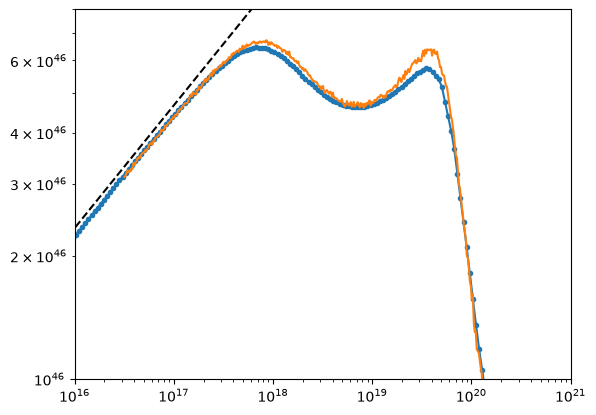

In [10]:
fig, ax = plt.subplots()

energy, spectrum = result.get_solution_group([101], epow=0)
energy *= 1e9
ax.loglog(energy, energy**3 * spectrum, ".-")

Eref, specref = simprop_ref
specref = specref / 5.15e6
ax.loglog(Eref, Eref**3 * specref)

ax.loglog(energy, 3.7e41 * energy ** (3 - 2.7), color="k", ls="--")

ax.set_xlim(1e16, 1e21)
ax.set_ylim(1e46, 8e46)